In [2]:
import os
os.chdir('/mnt/c/Users/hcam7/pbmc3k_scrna')
print("Working directory:", os.getcwd())

Working directory: /mnt/c/Users/hcam7/pbmc3k_scrna


In [3]:
import os
print(os.getcwd())
print(os.listdir('.'))

/mnt/c/Users/hcam7/pbmc3k_scrna
['.git', '.gitignore', 'cache', 'data', 'logs', 'notebooks', 'results']


In [4]:
import os
os.chdir('/mnt/c/Users/hcam7/pbmc3k_scrna')
print("Working directory:", os.getcwd())
print(os.listdir('.'))

Working directory: /mnt/c/Users/hcam7/pbmc3k_scrna
['.git', '.gitignore', 'cache', 'data', 'logs', 'notebooks', 'results']


In [5]:
import scanpy as sc
adata = sc.read_10x_mtx(
    'data/raw/filtered_gene_bc_matrices/hg19/',
    var_names='gene_symbols',
    cache=True
)

adata

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'

In [6]:
print("Type of adata.X:", type(adata.X))
print("Shape of adata.X:", adata.X.shape)

total_entries = adata.X.shape[0] * adata.X.shape[1]
nonzero_entries = adata.X.nnz
print(f"Total possible entries: {total_entries:,}")
print(f"Non-zero entries: {nonzero_entries:,}")
print(f"Fraction non-zero: {100 * nonzero_entries / total_entries:.2f}%")

Type of adata.X: <class 'scipy.sparse._csc.csc_matrix'>
Shape of adata.X: (2700, 32738)
Total possible entries: 88,392,600
Non-zero entries: 2,286,884
Fraction non-zero: 2.59%


In [7]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')
print("Mitochondrial genes flagged:", adata.var['mt'].sum())

sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

adata.obs[['total_counts', 'n_genes_by_counts', 'pct_counts_mt']].describe()

Mitochondrial genes flagged: 13


,total_counts,n_genes_by_counts,pct_counts_mt
count,2700.000000,2700.000000,2700.000000
mean,2366.900391,846.994074,2.215132
std,1094.262085,282.104964,1.165438
min,548.000000,212.000000,0.000000
25%,1757.750000,690.000000,1.536238
50%,2197.000000,817.000000,2.029639
75%,2763.000000,953.250000,2.640218
max,15844.000000,3422.000000,22.569027


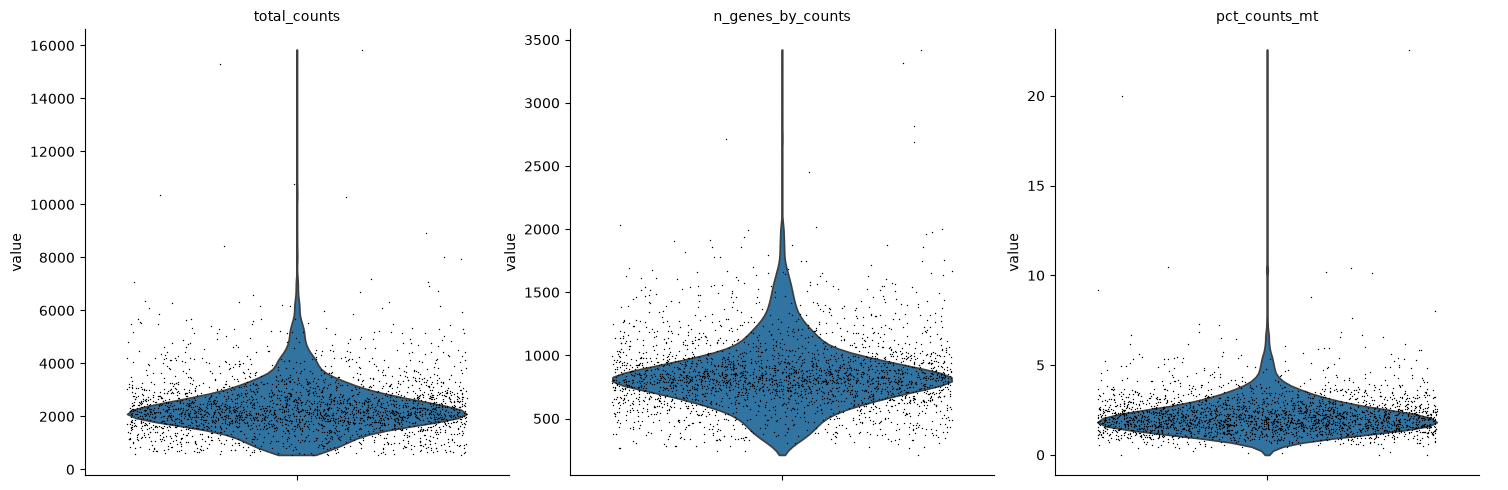

In [8]:
sc.pl.violin(adata, ['total_counts', 'n_genes_by_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True)

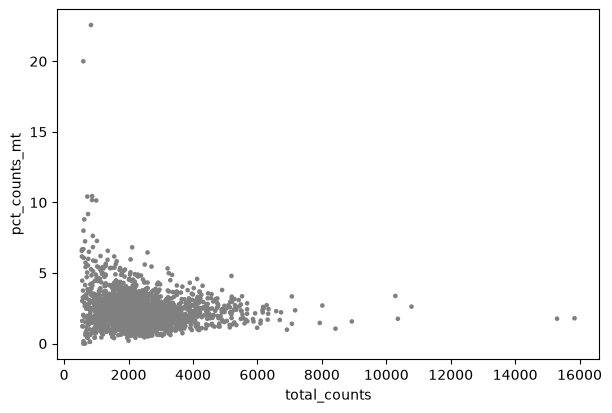

In [9]:
sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt')

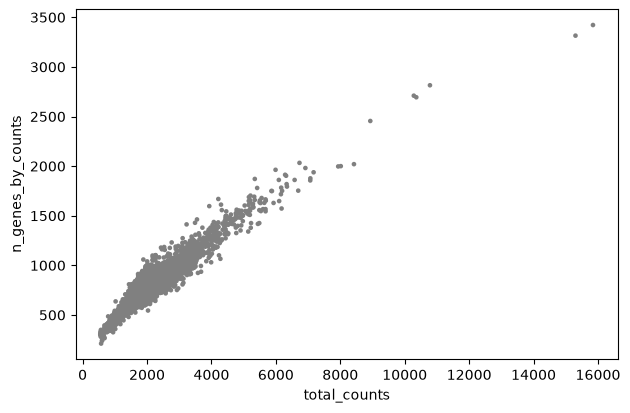

In [10]:
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts')

In [11]:
print("Before filtering:", adata.shape)

sc.pp.filter_genes(adata, min_cells=3)      # remove genes detected in fewer than 3 cells
sc.pp.filter_cells(adata, min_genes=200)     # floor: cells need at least 200 genes detected

adata = adata[adata.obs['n_genes_by_counts'] < 2500, :].copy()   # doublet ceiling
adata = adata[adata.obs['pct_counts_mt'] < 5, :].copy()          # dying-cell filter

print("After filtering:", adata.shape)

Before filtering: (2700, 32738)
After filtering: (2638, 13714)


In [12]:
sc.pp.scrublet(adata, random_state=0)

print("Predicted doublets:", adata.obs['predicted_doublet'].sum())
print(f"Doublet rate: {100 * adata.obs['predicted_doublet'].mean():.2f}%")

Predicted doublets: 43
Doublet rate: 1.63%


In [13]:
adata = adata[~adata.obs['predicted_doublet'], :].copy()
print("Final clean dataset:", adata.shape)

Final clean dataset: (2595, 13714)


In [14]:
print("Max value in .X (should be a whole number):", adata.X.max())

adata.layers['counts'] = adata.X.copy()
print("Layers now stored:", list(adata.layers.keys()))

Max value in .X (should be a whole number): 419.0
Layers now stored: ['counts']


In [15]:
sc.pp.normalize_total(adata, target_sum=1e4)   # CP10K: scale every cell to 10,000 total counts
sc.pp.log1p(adata)                               # log(x + 1)

print(".X max (now a small float):", adata.X.max())
print("counts layer max (still raw):", adata.layers['counts'].max())

.X max (now a small float): 7.4695992
counts layer max (still raw): 419.0


In [16]:
sc.pp.highly_variable_genes(
    adata, n_top_genes=2000,
    flavor='seurat_v3',      # this method expects raw counts...
    layer='counts'           # ...so we point it at the preserved counts layer
)

print("Highly variable genes:", adata.var['highly_variable'].sum())
print("Total genes:", adata.shape[1])

Highly variable genes: 2000
Total genes: 13714


In [17]:
hvg_ranked = adata.var[adata.var['highly_variable']].sort_values('highly_variable_rank')
print("Top 15 HVGs:", list(hvg_ranked.index[:15]))

Top 15 HVGs: ['PPBP', 'S100A9', 'LYZ', 'IGLL5', 'GNLY', 'FTL', 'PF4', 'FTH1', 'HLA-DRA', 'S100A8', 'FCER1A', 'GNG11', 'CD74', 'CLU', 'NKG7']


In [18]:
adata.raw = adata                                            # freeze log-normalized, ALL genes
adata = adata[:, adata.var['highly_variable']].copy()         # subset to 2,000 HVGs

sc.pp.scale(adata, max_value=10)                              # z-score each gene, clip at 10

print("Subset to HVGs:", adata.shape)
print(".X mean (~0):", round(float(adata.X.mean()), 4))
print(".X max/min (clipped):", adata.X.max(), adata.X.min())

Subset to HVGs: (2595, 2000)
.X mean (~0): -0.0043
.X max/min (clipped): 10.0 -10.0


/home/hcam7/miniconda3/envs/pbmc3k_scrna/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [19]:
sc.tl.pca(adata, svd_solver='arpack', n_comps=50)

for i, vr in enumerate(adata.uns['pca']['variance_ratio'][:6]):
    print(f"PC{i+1}: {vr*100:.2f}%")

PC1: 2.91%
PC2: 1.18%
PC3: 0.91%
PC4: 0.82%
PC5: 0.58%
PC6: 0.38%


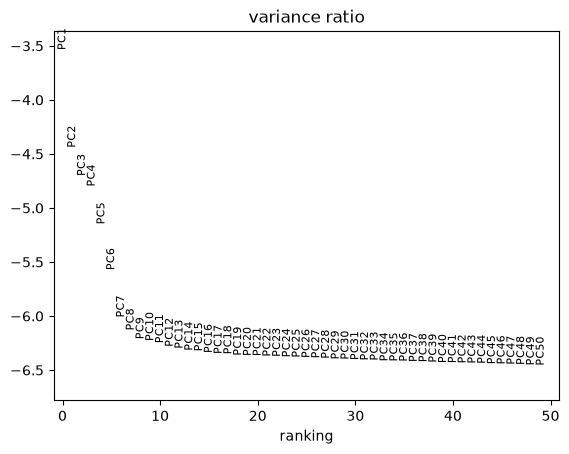

In [20]:
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

In [21]:
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=10)
sc.tl.umap(adata, random_state=0)

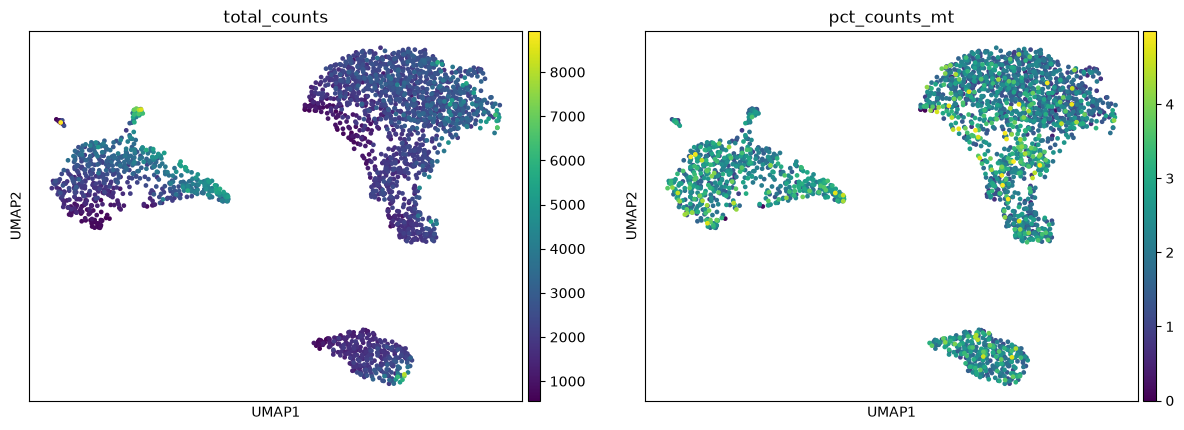

In [22]:
sc.pl.umap(adata, color=['total_counts', 'pct_counts_mt'])

Clusters found: 9


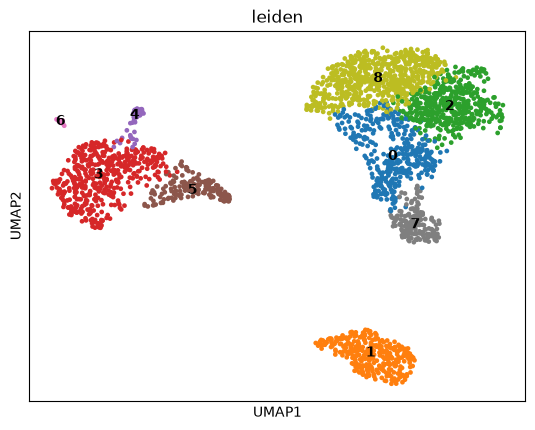

In [23]:
sc.tl.leiden(adata, resolution=0.5, random_state=0, flavor='igraph', n_iterations=2)
print("Clusters found:", adata.obs['leiden'].nunique())
sc.pl.umap(adata, color='leiden', legend_loc='on data')

In [24]:
sc.tl.rank_genes_groups(
    adata, groupby='leiden', method='wilcoxon',
    use_raw=True, key_added='rank_genes'
)

In [25]:
df = sc.get.rank_genes_groups_df(adata, group='3', key='rank_genes')
print(df.head(6).to_string(index=False))

 names    scores  logfoldchanges         pvals     pvals_adj
   LYZ 32.949963        6.207274 4.235719e-238 5.808865e-234
S100A9 32.916538        7.376136 1.274679e-237 8.740474e-234
S100A8 32.161831        7.531244 6.035328e-227 2.758949e-223
TYROBP 31.201319        5.500757 1.022458e-213 3.505499e-210
   FTL 30.618025        3.509089 7.045429e-206 1.932420e-202
  FCN1 30.409227        5.639821 4.147830e-203 9.480557e-200


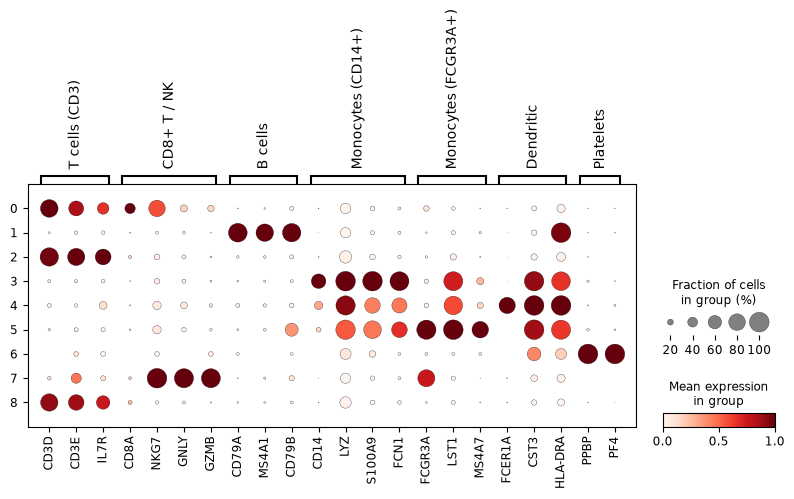

In [26]:
marker_genes = {
    'T cells (CD3)':        ['CD3D', 'CD3E', 'IL7R'],
    'CD8+ T / NK':           ['CD8A', 'NKG7', 'GNLY', 'GZMB'],
    'B cells':                ['CD79A', 'MS4A1', 'CD79B'],
    'Monocytes (CD14+)':     ['CD14', 'LYZ', 'S100A9', 'FCN1'],
    'Monocytes (FCGR3A+)':   ['FCGR3A', 'LST1', 'MS4A7'],
    'Dendritic':              ['FCER1A', 'CST3', 'HLA-DRA'],
    'Platelets':              ['PPBP', 'PF4'],
}

sc.pl.dotplot(adata, marker_genes, groupby='leiden', use_raw=True, standard_scale='var')

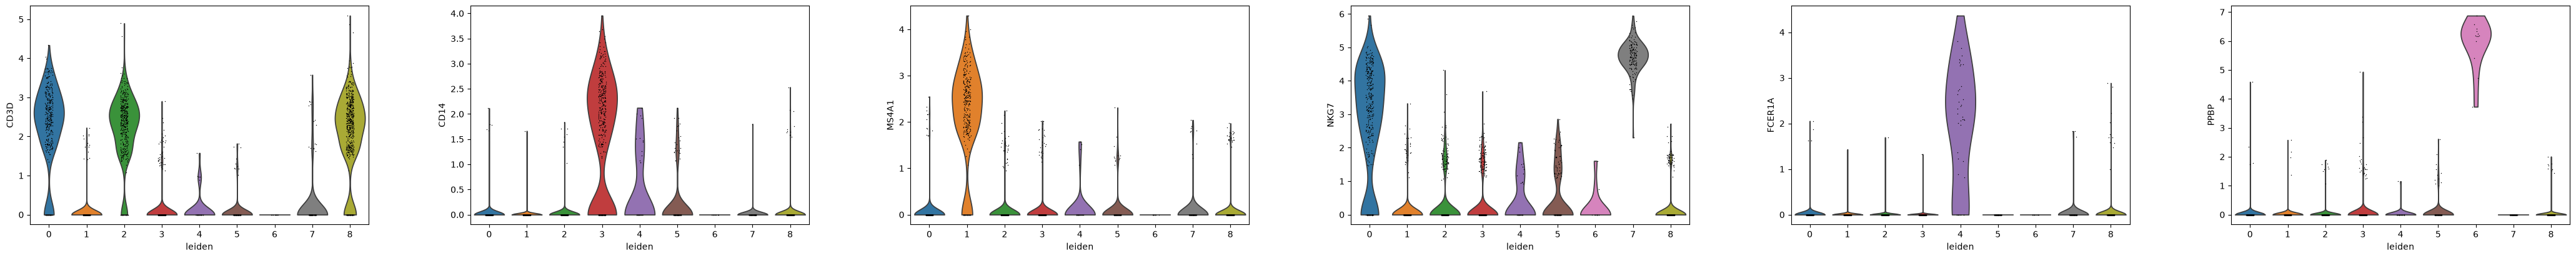

In [27]:
sc.pl.violin(adata, ['CD3D','CD14','MS4A1','NKG7','FCER1A','PPBP'],
             groupby='leiden', use_raw=True)

In [28]:
cluster_to_celltype = {
    '0': 'CD8+ T / Cytotoxic',
    '1': 'B cells',
    '2': 'CD4+ T cells',
    '3': 'CD14+ Monocytes',
    '4': 'Dendritic cells',
    '5': 'FCGR3A+ Monocytes',
    '6': 'Platelets',
    '7': 'NK cells',
    '8': 'Naive CD4+ T cells',
}

adata.obs['cell_type'] = adata.obs['leiden'].map(cluster_to_celltype).astype('category')
print(adata.obs['cell_type'].value_counts())

cell_type
Naive CD4+ T cells    628
CD14+ Monocytes       456
CD4+ T cells          445
CD8+ T / Cytotoxic    374
B cells               326
FCGR3A+ Monocytes     158
NK cells              154
Dendritic cells        41
Platelets              13
Name: count, dtype: int64


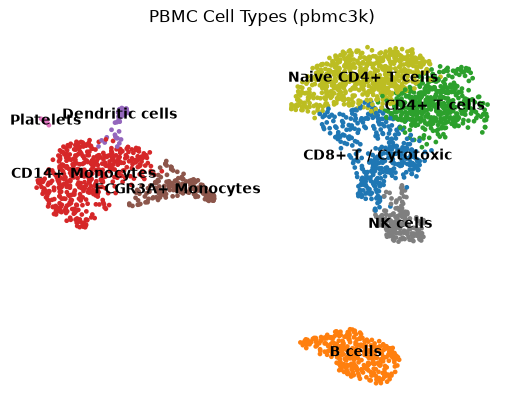

In [29]:
sc.pl.umap(adata, color='cell_type', legend_loc='on data',
           frameon=False, title='PBMC Cell Types (pbmc3k)')

adata.write('data/processed/pbmc3k_annotated.h5ad')

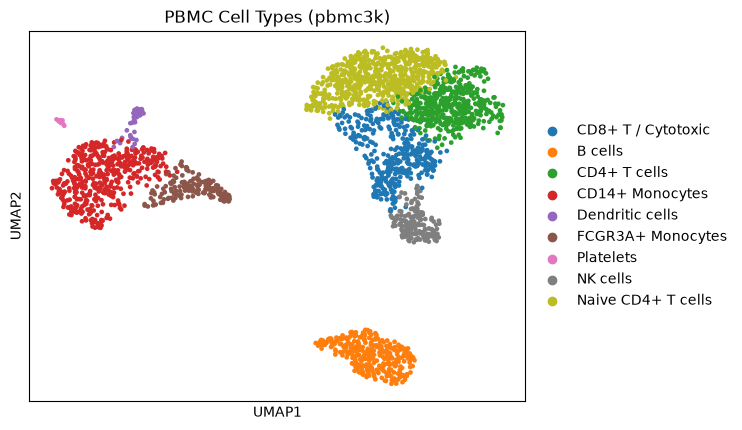

In [30]:
sc.pl.umap(adata, color='cell_type', legend_loc='right margin',
           title='PBMC Cell Types (pbmc3k)')